# 03 - Clustering
Loan Default Prediction Capstone

Goal: run K-Means on the preprocessed features to discover natural borrower segments, then generate a `Cluster_ID` feature to test as an input to the classifiers in notebook 04.

This is the first notebook that actually trains a model.

## 1. Load Preprocessed Data

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import joblib
import os

df = pd.read_csv('../data/preprocessed_data.csv')
df.shape

(255347, 25)

## 2. Separate Features for Clustering
`Default` is excluded — it's the target for classification later, and must not leak into an unsupervised step.

In [10]:
feature_cols = [col for col in df.columns if col != 'Default']
X = df[feature_cols]
print("Features used for clustering:", len(feature_cols))
X.head()

Features used for clustering: 24


,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,EmploymentType_Part-time,...,Education_Master's,Education_PhD,LoanPurpose_Business,LoanPurpose_Education,LoanPurpose_Home,LoanPurpose_Other,HasMortgage_Yes,HasDependents_Yes,MaritalStatus_Married,MaritalStatus_Single
0,0.833990,0.089693,-1.086833,-0.341492,0.590533,1.341937,0.261771,-0.001526,-0.260753,False,...,False,False,False,False,False,True,True,True,False,False
1,1.701221,-0.823021,-0.044309,-0.731666,-1.285731,-1.343791,-1.308350,1.412793,0.778585,False,...,True,False,False,False,False,True,False,False,True,False
2,0.166888,0.043854,0.022715,-0.775718,-0.968209,0.446694,1.156831,-0.708685,-0.823728,False,...,True,False,False,False,False,False,True,True,False,False
3,-0.767053,-1.303452,-1.168538,1.061875,-1.718715,0.446694,-0.967805,-0.708685,-1.170174,False,...,False,False,True,False,False,False,False,False,True,False
4,1.100830,-1.592855,-1.671921,0.369631,-1.487790,1.341937,-1.052188,0.705634,0.995114,False,...,False,False,False,False,False,False,False,True,False,False


## 3. Elbow Method
Running K-Means across a range of K values and plotting inertia (within-cluster sum of squares) to look for the 'elbow' point.

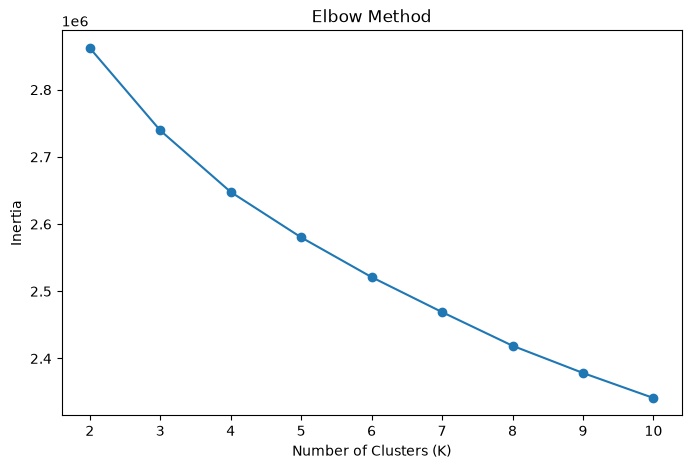

In [11]:
inertia = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X)
    inertia.append(km.inertia_)

plt.figure(figsize=(8,5))
plt.plot(list(k_range), inertia, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

## 4. Silhouette Score
Cross-checking the elbow result against silhouette score across the same range of K. Note: on 255K rows, computing silhouette score on the full dataset is expensive — sampling a subset keeps this practical.

K=2: Silhouette Score = 0.0661
K=3: Silhouette Score = 0.0547
K=4: Silhouette Score = 0.0557
K=5: Silhouette Score = 0.0530
K=6: Silhouette Score = 0.0529
K=7: Silhouette Score = 0.0538
K=8: Silhouette Score = 0.0537
K=9: Silhouette Score = 0.0550
K=10: Silhouette Score = 0.0550


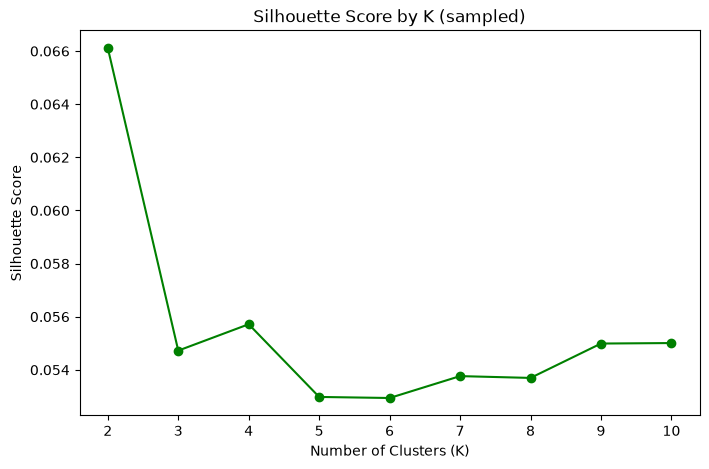

In [12]:
sample_idx = np.random.RandomState(42).choice(X.index, size=10000, replace=False)
X_sample = X.loc[sample_idx]

silhouette_scores = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_sample)
    score = silhouette_score(X_sample, labels)
    silhouette_scores.append(score)
    print(f"K={k}: Silhouette Score = {score:.4f}")

plt.figure(figsize=(8,5))
plt.plot(list(k_range), silhouette_scores, marker='o', color='green')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score by K (sampled)')
plt.show()

## 5. Choose K and Fit Final Model
Pick K based on the elbow point and silhouette score above — adjust `chosen_k` after reviewing the plots. Domain judgment matters here too: too few clusters (e.g., K=2) may be statistically 'cleanest' but less useful for real borrower segmentation.

In [13]:
chosen_k = 4  # adjust based on elbow + silhouette results above

kmeans_final = KMeans(n_clusters=chosen_k, random_state=42, n_init=10)
df['Cluster_ID'] = kmeans_final.fit_predict(X)

df['Cluster_ID'].value_counts().sort_index()

Cluster_ID
0    62089
1    65510
2    62878
3    64870
Name: count, dtype: int64

## 6. Cluster Interpretation
Mean feature values per cluster — this is how we figure out what each cluster actually represents (e.g., 'high income, low DTI' vs 'low income, high DTI').

In [14]:
cluster_summary = df.groupby('Cluster_ID')[feature_cols].mean()
cluster_summary

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,EmploymentType_Part-time,...,Education_Master's,Education_PhD,LoanPurpose_Business,LoanPurpose_Education,LoanPurpose_Home,LoanPurpose_Other,HasMortgage_Yes,HasDependents_Yes,MaritalStatus_Married,MaritalStatus_Single
Cluster_ID,,,,,,,,,,,,,,,,,,,,,
0,0.839188,0.022522,-0.193889,-0.007874,0.000231,0.037895,-0.039498,-0.936611,-0.026886,0.249626,...,0.250028,0.247242,0.201565,0.199858,0.200277,0.200196,0.500234,0.498559,0.334761,0.331572
1,-0.799297,0.000926,0.016406,0.003839,0.006624,0.960294,0.003450,0.019178,0.010673,0.254373,...,0.249229,0.250862,0.202961,0.200641,0.200779,0.198122,0.500076,0.501572,0.334865,0.333995
2,0.839583,-0.028346,0.172494,0.003135,0.000454,-0.049393,0.027420,0.929091,0.004934,0.250056,...,0.249833,0.249054,0.198082,0.199386,0.200706,0.201263,0.499459,0.502529,0.334775,0.330704
3,-0.809829,0.004985,0.001812,0.000621,-0.007351,-0.958162,0.007742,-0.023470,0.010173,0.250886,...,0.246354,0.248065,0.200894,0.199090,0.201603,0.198088,0.500277,0.498397,0.331895,0.335301


In [15]:
# Default rate per cluster - a useful early signal of whether clusters relate to risk at all
df.groupby('Cluster_ID')['Default'].mean().sort_values(ascending=False)

Cluster_ID
1    0.169882
3    0.148975
2    0.074605
0    0.067146
Name: Default, dtype: float64

## 8. Save Outputs
`kmeans_model.pkl` will be reused at Streamlit prediction time to assign a Cluster_ID to any new user input. `preprocessed_data_with_clusters.csv` feeds directly into 04_classification.ipynb.

In [25]:
os.makedirs('../models', exist_ok=True)

joblib.dump(kmeans_final, '../models/kmeans_model.pkl')
df.to_csv('../data/preprocessed_data_with_clusters.csv', index=False)

print("Saved: models/kmeans_model.pkl")
print("Saved: data/preprocessed_data_with_clusters.csv")
print("Final shape:", df.shape)

Saved: models/kmeans_model.pkl
Saved: data/preprocessed_data_with_clusters.csv
Final shape: (255347, 26)


## 9. Notes / Findings
(Fill in after running: chosen K and why, what each cluster seems to represent based on the summary table, whether default rate varies meaningfully across clusters — this last point is the key thing to report, since it hints at whether Cluster_ID will actually help classification in notebook 04.)